# Galaxian - DQN Reinforcement Learning 👾

## 1. Imports
Libraries for the Atari environment (Gymnasium + ALE), neural network (PyTorch), and utilities.

In [1]:
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Environment
Load the Galaxian Atari game using RAM observations (128 bytes representing the game state).

In [5]:
env = gym.make("ALE/Galaxian-v5", obs_type="ram")
print(f"Observation: {env.observation_space}")
print(f"Actions: {env.action_space}")
env.close()

Observation: Box(0, 255, (128,), uint8)
Actions: Discrete(6)


## 3. Replay Buffer
Stores transitions (state, action, reward, next_state, done) and samples random batches to break temporal correlation.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions),
                np.array(rewards, dtype=np.float32),
                np.array(next_states),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

## 4. Build Model
MLP neural network that takes the RAM state (128 values) and outputs Q-values for each possible action.

In [7]:
class QNetwork(nn.Module):
    def __init__(self, input_size, n_actions):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.network(x)

## 5. Agent
DQN agent with epsilon-greedy exploration, experience replay, and a target network for stable training.

In [8]:
class DQNAgent:
    def __init__(self, input_size, n_actions, lr, gamma, epsilon, epsilon_min,
                 epsilon_decay, buffer_size, batch_size, target_update):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.steps = 0

        self.q_net = QNetwork(input_size, n_actions).to(device)
        self.target_net = QNetwork(input_size, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.memory = ReplayBuffer(buffer_size)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_net(state_t).argmax().item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        s = torch.FloatTensor(states).to(device)
        a = torch.LongTensor(actions).to(device)
        r = torch.FloatTensor(rewards).to(device)
        s2 = torch.FloatTensor(next_states).to(device)
        d = torch.FloatTensor(dones).to(device)

        q_values = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            q_target = r + (1 - d) * self.gamma * self.target_net(s2).max(1)[0]

        loss = self.loss_fn(q_values, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## 6. Hyperparameters
All configurable training parameters. Modify this cell and re-run to experiment.

In [9]:
N_EPISODES    = 1000
MAX_STEPS     = 10000
LR            = 0.0001
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_MIN   = 0.02
EPSILON_DECAY = 0.995
BUFFER_SIZE   = 100000
BATCH_SIZE    = 64
TARGET_UPDATE = 1000
MODEL_PATH    = "modelos/galaxian_v3.pth"

## 7. Training
Main training loop: the agent plays episodes, stores experiences, and updates the Q-network using the Bellman equation.

In [10]:
env = gym.make("ALE/Galaxian-v5", obs_type="ram")
input_size = env.observation_space.shape[0]
n_actions = env.action_space.n

agent = DQNAgent(input_size, n_actions, LR, GAMMA, EPSILON_START,
                 EPSILON_MIN, EPSILON_DECAY, BUFFER_SIZE, BATCH_SIZE, TARGET_UPDATE)

reward_history = []
loss_history = []
best_reward = -float('inf')

for ep in range(N_EPISODES):
    state, _ = env.reset()
    state = state / 255.0
    total_reward = 0
    total_loss = 0
    n_updates = 0

    for step in range(MAX_STEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = next_state / 255.0
        done = terminated or truncated

        agent.memory.add(state, action, reward, next_state, done)
        loss = agent.train_step()
        if loss > 0:
            total_loss += loss
            n_updates += 1

        total_reward += reward
        state = next_state
        if done:
            break

    agent.decay_epsilon()
    reward_history.append(total_reward)
    loss_history.append(total_loss / max(n_updates, 1))

    if total_reward > best_reward:
        best_reward = total_reward
        torch.save(agent.q_net.state_dict(), MODEL_PATH)

    if (ep + 1) % 25 == 0:
        avg = np.mean(reward_history[-25:])
        print(f"Ep {ep+1:4d}/{N_EPISODES} | Rew: {total_reward:6.0f} | "
              f"Avg(25): {avg:7.1f} | Best: {best_reward:6.0f} | "
              f"Eps: {agent.epsilon:.4f}")

env.close()
print(f"\nDone! Best: {best_reward} | Model: {MODEL_PATH}")

Ep   25/1000 | Rew:    610 | Avg(25):   658.0 | Best:   1530 | Eps: 0.8822
Ep   50/1000 | Rew:    790 | Avg(25):   681.2 | Best:   1530 | Eps: 0.7783
Ep   75/1000 | Rew:    510 | Avg(25):   770.8 | Best:   1530 | Eps: 0.6866
Ep  100/1000 | Rew:    620 | Avg(25):   607.6 | Best:   1530 | Eps: 0.6058
Ep  125/1000 | Rew:   1120 | Avg(25):   726.4 | Best:   1530 | Eps: 0.5344
Ep  150/1000 | Rew:    490 | Avg(25):   710.0 | Best:   1580 | Eps: 0.4715
Ep  175/1000 | Rew:    390 | Avg(25):   668.8 | Best:   1580 | Eps: 0.4159
Ep  200/1000 | Rew:    450 | Avg(25):   639.6 | Best:   1580 | Eps: 0.3670
Ep  225/1000 | Rew:    270 | Avg(25):   763.6 | Best:   1850 | Eps: 0.3237
Ep  250/1000 | Rew:    620 | Avg(25):   823.2 | Best:   1950 | Eps: 0.2856
Ep  275/1000 | Rew:    740 | Avg(25):   694.4 | Best:   1950 | Eps: 0.2520
Ep  300/1000 | Rew:    830 | Avg(25):   826.4 | Best:   2030 | Eps: 0.2223
Ep  325/1000 | Rew:    360 | Avg(25):   671.6 | Best:   2030 | Eps: 0.1961
Ep  350/1000 | Rew:    73

## 8. Results
Plot the learning curve (reward per episode) and training loss over time.

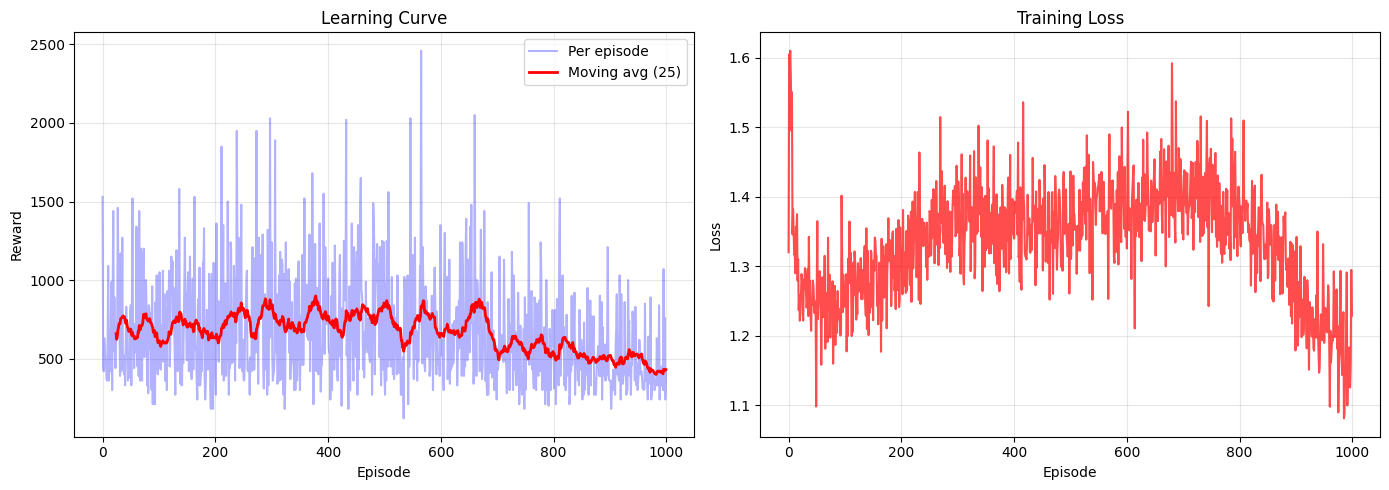

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w = 25
axes[0].plot(reward_history, alpha=0.3, color='blue', label='Per episode')
if len(reward_history) >= w:
    avg = np.convolve(reward_history, np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(reward_history)), avg, 'r-', lw=2, label=f'Moving avg ({w})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history, alpha=0.7, color='red')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_PATH.replace('.pth', '.png'), dpi=150)
plt.show()

## 9. Save & Evaluate
Load the best model and test it over 10 games with no exploration (epsilon = 0).

In [13]:
agent.q_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
agent.epsilon = 0
print(f"Model loaded: {MODEL_PATH}")

env_eval = gym.make("ALE/Galaxian-v5", obs_type="ram")
eval_rewards = []

for ep in range(10):
    state, _ = env_eval.reset()
    state = state / 255.0
    total = 0
    for _ in range(MAX_STEPS):
        action = agent.select_action(state)
        next_s, reward, term, trunc, _ = env_eval.step(action)
        total += reward
        state = next_s / 255.0
        if term or trunc:
            break
    eval_rewards.append(total)
    print(f"  Game {ep+1:2d}: {total:.0f}")

env_eval.close()
print(f"\nAvg: {np.mean(eval_rewards):.1f} | Std: {np.std(eval_rewards):.1f} | "
      f"Best: {np.max(eval_rewards):.0f} | Worst: {np.min(eval_rewards):.0f}")

Model loaded: modelos/galaxian_v3.pth
  Game  1: 860
  Game  2: 670
  Game  3: 620
  Game  4: 740
  Game  5: 550
  Game  6: 510
  Game  7: 1010
  Game  8: 800
  Game  9: 550
  Game 10: 800

Avg: 711.0 | Std: 151.8 | Best: 1010 | Worst: 510


## 10. Watch it play
Record a game as a GIF to visually see how the trained agent plays Galaxian.

GIF saved: modelos/galaxian_v3.gif (89 frames)


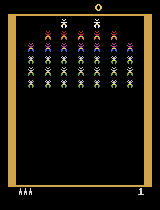

In [14]:
from PIL import Image
from IPython.display import Image as IPImage, display

agent.q_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
agent.epsilon = 0

env_vis = gym.make("ALE/Galaxian-v5", obs_type="ram", render_mode="rgb_array")
frames = []
state, _ = env_vis.reset()
frames.append(env_vis.render())
state = state / 255.0

for _ in range(3000):
    action = agent.select_action(state)
    next_s, reward, term, trunc, _ = env_vis.step(action)
    frames.append(env_vis.render())
    state = next_s / 255.0
    if term or trunc:
        break

env_vis.close()

gif_path = MODEL_PATH.replace('.pth', '.gif')
frames_pil = [Image.fromarray(f) for f in frames[::3]]
frames_pil[0].save(gif_path, save_all=True, append_images=frames_pil[1:], duration=50, loop=0)
print(f"GIF saved: {gif_path} ({len(frames_pil)} frames)")
display(IPImage(filename=gif_path))